In [ ]:
from google.colab import userdata
token = userdata.get('githubtoken')
!git clone https://github.com/Legend-Recalls/BlackBox-Problem.git

Cloning into 'BlackBox-Problem'...
remote: Enumerating objects: 4, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 4 (delta 0), reused 4 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (4/4), 33.98 KiB | 1.54 MiB/s, done.


In [ ]:
from oracle import quote, queries_used, reset_counter
price = quote(
weight_kg=2.0, # float, 0.1 to 100
distance_km=100.0, # float, 1 to 5000
category="standard", # one of: standard, electronics, fragile, books, clothing, food
express=False, # bool
coupon="", # str - "WELCOME10" or ""
)
queries_used() # Returns the number of quote() calls made.
# reset_counter()
print(price , queries_used())

reset_counter()

330.0 201


# first test for weight_kg

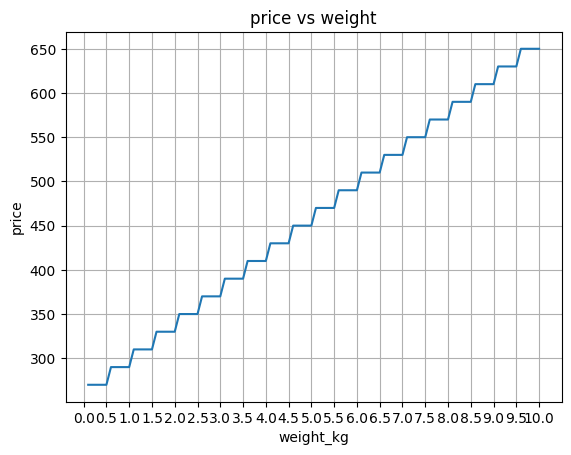

In [ ]:
import matplotlib.pyplot as plt
from oracle import quote, reset_counter
import numpy as np
weights = []

for x in range(1, 101):
    weights.append(x / 10)

prices = []

for weight in weights:
    price = quote(weight, 100, "standard", False, "")
    prices.append(price)

plt.figure()
plt.plot(weights, prices)

plt.xticks(np.arange(0, 10.1, 0.5)) #x axis mein details plot
plt.xlabel("weight_kg")
plt.ylabel("price")
plt.title("price vs weight")

plt.grid(True)
plt.show()

**increase in weight is not linear but in ranges of 0.5**

`formula = (rest of the parameters base) + weight`



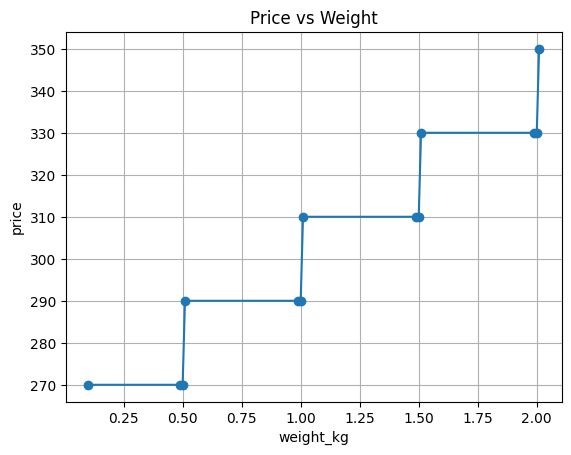

In [ ]:
weights = [0.1, 0.49, 0.50, 0.51, 0.99, 1.0, 1.01, 1.49, 1.50, 1.51, 1.99, 2.0, 2.01]

prices = []

for weight in weights:
    price = quote(weight, 100, "standard", False, "")
    prices.append(price)

plt.figure()
plt.plot(weights, prices, marker="o")

plt.xlabel("weight_kg")
plt.ylabel("price")
plt.title("Price vs Weight")
plt.grid(True)
plt.show()

**₹20 increase for every additional 0.5 range**

# test 2: distance_km

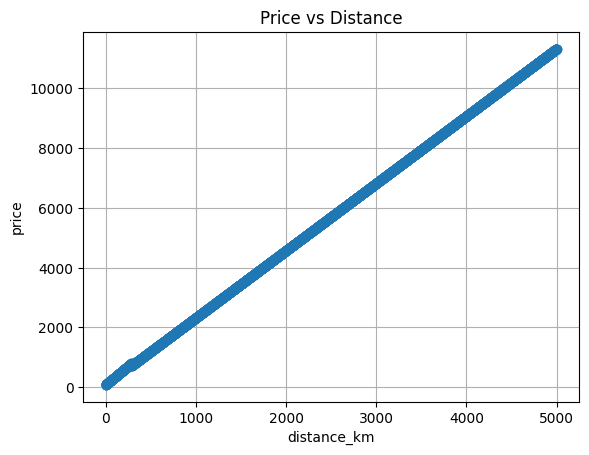

In [ ]:
import matplotlib.pyplot as plt
from oracle import quote

distances = []
for distance in range(1, 5001): #1 to 5000 was linear but we saw a notch so we are zooming to 1 to 1000
    distances.append(distance)

prices = []
for distance in distances:
    price = quote(2.0, distance, "standard", False, "")
    prices.append(price)

plt.figure()
plt.plot(distances, prices, marker="o")
plt.xlabel("distance_km")
plt.ylabel("price")
plt.title("Price vs Distance")

plt.grid(True)

plt.show()

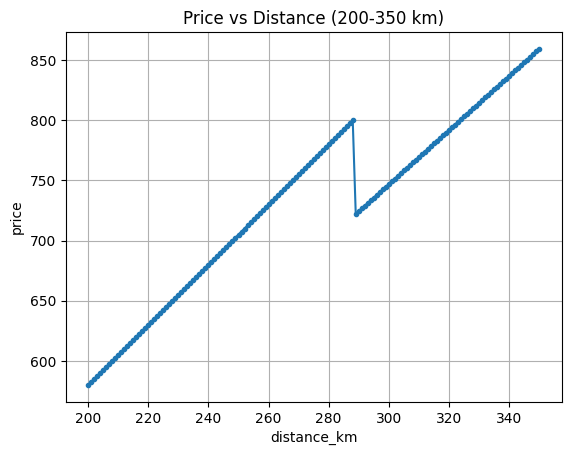

In [ ]:
distances = []

for distance in range(200, 351):
    distances.append(distance)

prices = []

for distance in distances:
    price = quote(2.0, distance, "standard", False, "")
    prices.append(price)

plt.figure()

plt.plot(distances, prices, marker="o", markersize=3)

plt.xlabel("distance_km")
plt.ylabel("price")
plt.title("Price vs Distance (200-350 km)")

plt.grid(True)
plt.show()

In [ ]:
distances = []
for distance in range(280, 296):
    distances.append(distance)

prices = []
for distance in distances:
    price = quote(2.0, distance, "standard", False, "")
    prices.append(price)

for distance, price in zip(distances, prices):
    print(distance, price)

280 780.0
281 782.5
282 785.0
283 787.5
284 790.0
285 792.5
286 795.0
287 797.5
288 800.0
289 722.25
290 724.5
291 726.75
292 729.0
293 731.25
294 733.5
295 735.75


threshold is between **288** and **289** as there is a huge drop in price

before the threshold : **₹2.50/km**
after the threshold : **₹2.25/km**

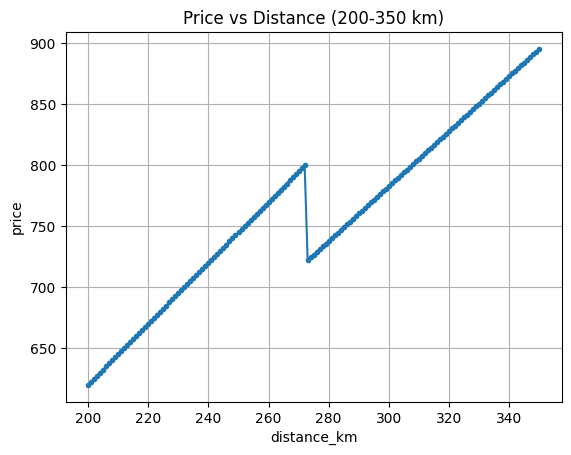

In [ ]:
distances = []

for distance in range(200, 351):
    distances.append(distance)

prices = []

for distance in distances:
    price = quote(3.0, distance, "standard", False, "")
    prices.append(price)

plt.figure()

plt.plot(distances, prices, marker="o", markersize=3)

plt.xlabel("distance_km")
plt.ylabel("price")
plt.title("Price vs Distance (200-350 km)")

plt.grid(True)
plt.show()

there's a 10% discount starting at 289 km as 2.5 becomes 2.25 and 80 becomes 72


```
if distance <= 288:
    price = 80 + 2.5 × distance

if distance >= 289:
    price = (80 + 2.5 × distance) × 0.90

```


the same rule works in 3.0 but at ~275

idea: **breakpoint decreases by 10 km for every +1 kg**


In [ ]:
weights = [1.0, 2.0, 3.0, 4.0, 5.0]

for weight in weights:
    print("Weight:", weight)
#as we incrase distance, price always increase but at some point it has a gap
    previous_price = quote(weight, 1, "standard", False, "")

    for distance in range(2, 350):
        price = quote(weight, distance, "standard", False, "")

        if price < previous_price:
            print("Breakpoint:", distance)

        previous_price = price

Weight: 1.0
Breakpoint: 305
Weight: 2.0
Breakpoint: 289
Weight: 3.0
Breakpoint: 273
Weight: 4.0
Breakpoint: 257
Weight: 5.0
Breakpoint: 241


idea: **breakpoint decreases by 10 km for every +1 kg**

result: **breakpoint decreases by 16 km for every +1 kg**

`breakpoint = 321 - 16 × weight`

---
```
price = 40 * range(weight) + 2.5 * distance

breakpoint = 321 - 16 * weight

if distance >= breakpoint:
    price = price * 0.90

```

**last check: whether we use range(weight) or just weight**




In [ ]:
distances = [288, 288.1, 288.2, 288.3, 288.4, 288.5,
             288.6, 288.7, 288.8, 288.9, 289]

for distance in distances:
    price = quote(2, distance, "standard", False, "")
    print(distance, price)

288 800.0
288.1 720.23
288.2 720.45
288.3 720.68
288.4 720.9
288.5 721.12
288.6 721.35
288.7 721.58
288.8 721.8
288.9 722.02
289 722.25


In [ ]:
distances = [272, 272.1, 272.2, 272.3, 272.4, 272.5,
             272.6, 272.7, 272.8, 272.9, 273]

for distance in distances:
    price = quote(3, distance, "standard", False, "")
    print(distance, price)

272 800.0
272.1 720.23
272.2 720.45
272.3 720.68
272.4 720.9
272.5 721.12
272.6 721.35
272.7 721.58
272.8 721.8
272.9 722.02
273 722.25


according to our idea 288 to 289 is breakpoint for 2
ad 273 is breakpoint for 3. consistently 800 is there. so distance might not be affecting here but as soon as price reaches 800 it goes down
```
Weight:
    round UP to nearest 0.5 kg
    every 0.5 kg → +20

Distance:
    +2.5 per km

Base price:
    40 × rounded_weight + 2.5 × distance

Discount:
    if base price > 800:
        10% discount

```




# test 3: category

In [ ]:
from oracle import quote
for c in ["standard","electronics","fragile","books","clothing","food"]:
    print(c, quote(2.0, 100, c, False, "")) #base = 20 * 40 + 2.5*100 = 330

standard 330.0
electronics 429.0
fragile 480.0
books 330.0
clothing 330.0
food 330.0


standard,books,clothing,food --- 1x

electronics --- 429/330 = 1.3x

fragile --- ×1.4545


this suggest maybe its not a direct multiplier

In [ ]:
from oracle import quote

weights = [1.0, 2.0, 3.0]
distances = [0, 100, 200]

for weight in weights:

    for distance in distances:

        for c in ["standard", "electronics", "fragile",
                  "books", "clothing", "food"]:

            price = quote(weight, distance, c, False, "")

            print(
                "weight =", weight,
                "distance =", distance,
                "category =", c,
                "price =", price
            )

        print()

weight = 1.0 distance = 0 category = standard price = 40.0
weight = 1.0 distance = 0 category = electronics price = 52.0
weight = 1.0 distance = 0 category = fragile price = 190.0
weight = 1.0 distance = 0 category = books price = 40.0
weight = 1.0 distance = 0 category = clothing price = 40.0
weight = 1.0 distance = 0 category = food price = 40.0

weight = 1.0 distance = 100 category = standard price = 290.0
weight = 1.0 distance = 100 category = electronics price = 377.0
weight = 1.0 distance = 100 category = fragile price = 440.0
weight = 1.0 distance = 100 category = books price = 290.0
weight = 1.0 distance = 100 category = clothing price = 290.0
weight = 1.0 distance = 100 category = food price = 290.0

weight = 1.0 distance = 200 category = standard price = 540.0
weight = 1.0 distance = 200 category = electronics price = 702.0
weight = 1.0 distance = 200 category = fragile price = 690.0
weight = 1.0 distance = 200 category = books price = 540.0
weight = 1.0 distance = 200 catego

electronics is consistently 1.3x

books clothing food standard all 1x

fragile is always +150 from standard
```
rounded_weight = round_up_to_0.5(weight)

base = 40 * rounded_weight + 2.5 * distance

if category == "electronics":
    price = base * 1.3

elif category == "fragile":
    price = base + 150

else:
    price = base

```





In [ ]:
print(quote(2.0, 230, "fragile", False, "")) #check if discount comes after fragile or before fragile

724.5


discount must come at last

# test 4: express

In [ ]:
from oracle import quote
print(quote(2.0, 100, "standard", False, ""))
print(quote(2.0, 100, "standard", True, ""))


330.0
330.0


In [ ]:
from oracle import quote

weights = [1.0, 2.0, 3.0]
distances = [0, 100, 200, 300, 400]

for weight in weights:
    for distance in distances:

        normal = quote(weight, distance, "standard", False, "")
        express = quote(weight, distance, "standard", True, "")

        print(
            "w =", weight,
            "d =", distance,
            "normal =", normal,
            "express =", express,
            "difference =", express - normal
        )

    print()

w = 1.0 d = 0 normal = 40.0 express = 40.0 difference = 0.0
w = 1.0 d = 100 normal = 290.0 express = 290.0 difference = 0.0
w = 1.0 d = 200 normal = 540.0 express = 540.0 difference = 0.0
w = 1.0 d = 300 normal = 790.0 express = 790.0 difference = 0.0
w = 1.0 d = 400 normal = 936.0 express = 936.0 difference = 0.0

w = 2.0 d = 0 normal = 80.0 express = 80.0 difference = 0.0
w = 2.0 d = 100 normal = 330.0 express = 330.0 difference = 0.0
w = 2.0 d = 200 normal = 580.0 express = 580.0 difference = 0.0
w = 2.0 d = 300 normal = 747.0 express = 747.0 difference = 0.0
w = 2.0 d = 400 normal = 972.0 express = 972.0 difference = 0.0

w = 3.0 d = 0 normal = 120.0 express = 120.0 difference = 0.0
w = 3.0 d = 100 normal = 370.0 express = 370.0 difference = 0.0
w = 3.0 d = 200 normal = 620.0 express = 620.0 difference = 0.0
w = 3.0 d = 300 normal = 783.0 express = 783.0 difference = 0.0
w = 3.0 d = 400 normal = 1008.0 express = 1008.0 difference = 0.0



In [ ]:
from oracle import quote

weights = [1.0, 2.0, 3.0]
distances = [0, 100, 200, 300, 400]
categories = ["standard", "electronics", "fragile"]

for weight in weights:

    for distance in distances:

        for category in categories:

            normal = quote(weight, distance, category, False, "")
            express = quote(weight, distance, category, True, "")

            print(
                "w =", weight,
                "d =", distance,
                "category =", category,
                "normal =", normal,
                "express =", express,
                "difference =", express - normal
            )

        print()

w = 1.0 d = 0 category = standard normal = 40.0 express = 40.0 difference = 0.0
w = 1.0 d = 0 category = electronics normal = 52.0 express = 52.0 difference = 0.0
w = 1.0 d = 0 category = fragile normal = 190.0 express = 190.0 difference = 0.0
w = 1.0 d = 0 category = books normal = 40.0 express = 40.0 difference = 0.0
w = 1.0 d = 0 category = clothing normal = 40.0 express = 40.0 difference = 0.0
w = 1.0 d = 0 category = food normal = 40.0 express = 40.0 difference = 0.0

w = 1.0 d = 100 category = standard normal = 290.0 express = 290.0 difference = 0.0
w = 1.0 d = 100 category = electronics normal = 377.0 express = 377.0 difference = 0.0
w = 1.0 d = 100 category = fragile normal = 440.0 express = 440.0 difference = 0.0
w = 1.0 d = 100 category = books normal = 290.0 express = 290.0 difference = 0.0
w = 1.0 d = 100 category = clothing normal = 290.0 express = 290.0 difference = 0.0
w = 1.0 d = 100 category = food normal = 290.0 express = 290.0 difference = 0.0

w = 1.0 d = 200 catego

express doenst affect any price

idea: maybe coupon affects it

In [ ]:
from oracle import quote

weights = [1.0, 2.0]
distances = [0, 100, 200]
categories = ["standard",, "fragile",
              "books",]

for weight in weights:

    for distance in distances:

        for category in categories:

            normal = quote(weight, distance, category, False, "")
            coupon = quote(weight, distance, category, False, "WELCOME10")

            print(
                "w =", weight,
                "d =", distance,
                "category =", category,
                "normal =", normal,
                "WELCOME10 =", coupon,
                "difference =", normal - coupon
            )

        print()

w = 1.0 d = 0 category = standard normal = 40.0 WELCOME10 = -60.0 difference = 100.0
w = 1.0 d = 0 category = electronics normal = 52.0 WELCOME10 = -48.0 difference = 100.0
w = 1.0 d = 0 category = fragile normal = 190.0 WELCOME10 = 90.0 difference = 100.0
w = 1.0 d = 0 category = books normal = 40.0 WELCOME10 = -60.0 difference = 100.0
w = 1.0 d = 0 category = clothing normal = 40.0 WELCOME10 = -60.0 difference = 100.0
w = 1.0 d = 0 category = food normal = 40.0 WELCOME10 = -60.0 difference = 100.0

w = 1.0 d = 100 category = standard normal = 290.0 WELCOME10 = 190.0 difference = 100.0
w = 1.0 d = 100 category = electronics normal = 377.0 WELCOME10 = 277.0 difference = 100.0
w = 1.0 d = 100 category = fragile normal = 440.0 WELCOME10 = 340.0 difference = 100.0
w = 1.0 d = 100 category = books normal = 290.0 WELCOME10 = 190.0 difference = 100.0
w = 1.0 d = 100 category = clothing normal = 290.0 WELCOME10 = 190.0 difference = 100.0
w = 1.0 d = 100 category = food normal = 290.0 WELCOME1

1. Weight rounding
2. Base price
3. Category modification
4. ₹800 threshold / 10% discount
5. WELCOME10 subtract ₹100

In [ ]:
queries_used()

655

# Reconstruction


In [ ]:
import math

def my_quote(weight, distance, category, express=False, coupon=""):

    # Round weight UP to nearest 0.5
    rounded_weight = math.ceil(weight / 0.5) * 0.5

    # Base price
    price = 40 * rounded_weight + 2.5 * distance

    # Category
    if category == "electronics":
        price = price * 1.30

    elif category == "fragile":
        price = price + 150

    # 10% discount
    if price > 800:
        price = price * 0.90

    # Coupon
    if coupon == "WELCOME10":
        price = price - 100

    return price

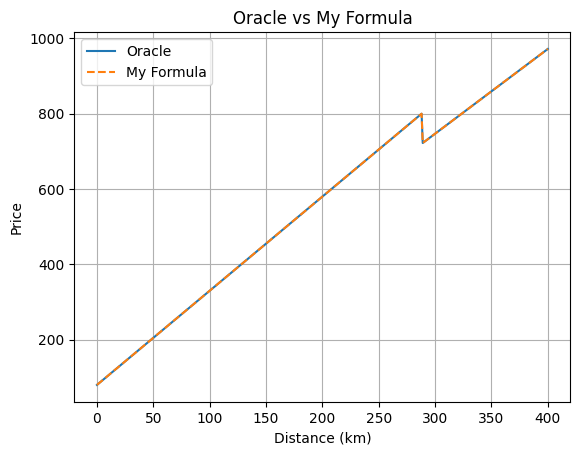

In [ ]:
import math
import matplotlib.pyplot as plt

from oracle import quote


def my_quote(weight, distance, category, express=False, coupon=""):

    rounded_weight = math.ceil(weight / 0.5) * 0.5

    price = 40 * rounded_weight + 2.5 * distance

    if category == "electronics":
        price = price * 1.30

    elif category == "fragile":
        price = price + 150

    if price > 800:
        price = price * 0.90

    if coupon == "WELCOME10":
        price = price - 100

    return price


weight = 2.0
category = "standard"

distances = []
oracle_prices = []
my_prices = []

for distance in range(0, 401):

    oracle_price = quote(
        weight, distance, category, False, ""
    )

    my_price = my_quote(
        weight, distance, category, False, ""
    )

    distances.append(distance)
    oracle_prices.append(round(oracle_price, 2))
    my_prices.append(round(my_price, 2))


plt.figure()

plt.plot(
    distances,
    oracle_prices,
    label="Oracle"
)

plt.plot(
    distances,
    my_prices,
    linestyle="--",
    label="My Formula"
)

plt.xlabel("Distance (km)")
plt.ylabel("Price")
plt.title("Oracle vs My Formula")

plt.legend()
plt.grid()

plt.show()